### Imports

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchinfo import summary

from utility_functions.classifier_engine import model_fit

import matplotlib.pyplot as plt

### Configuration

In [2]:
TRAIN_DIR = "./classification_data/train"
VALID_DIR = "./classification_data/val"
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 20
IMG_SIZE = 224
DEVICE = "mps" if torch.cuda.is_available() else "cpu"

### Data Augmentations

In [3]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Holograms are grayscale
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Dataset and Loader

In [4]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VALID_DIR, transform=val_transform)

train_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
with open('./checkpoint/class_indices.txt', 'w') as f:
    json.dump(train_dataset.class_to_idx, f, indent=4)

### Model (Transfer Learning)

In [6]:
model = torchvision.models.mobilenet_v2(weights="DEFAULT")

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.classifier[1].in_features
num_classes = 2

model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

summary(model=model, input_size=(32, 3, 224, 224), 
        col_names=["input_size", "output_size", "num_params", "params_percent", "trainable"], col_width=20)

Layer (type:depth-idx)                             Input Shape          Output Shape         Param #              Param %              Trainable
MobileNetV2                                        [32, 3, 224, 224]    [32, 2]              --                        --              Partial
├─Sequential: 1-1                                  [32, 3, 224, 224]    [32, 1280, 7, 7]     --                        --              False
│    └─Conv2dNormActivation: 2-1                   [32, 3, 224, 224]    [32, 32, 112, 112]   --                        --              False
│    │    └─Conv2d: 3-1                            [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                  0.03%              False
│    │    └─BatchNorm2d: 3-2                       [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                   0.00%              False
│    │    └─ReLU6: 3-3                             [32, 32, 112, 112]   [32, 32, 112, 112]   --                        --              --
│    └─Inv

In [7]:
model = model.to(DEVICE)

### Loss & Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

### Training

In [9]:
history = model_fit(model=model, train_loader=train_loader, val_loader=val_loader, 
                    loss_fn=criterion, optimizer=optimizer, device=DEVICE, epochs=EPOCHS, 
                    latest_checkpoint_path="./checkpoint/latest_mobilenet_v2.pth", 
                    best_checkpoint_path="./checkpoint/best_mobilenet_v2.pth")

[INFO] Loading checkpoint from ./checkpoint/latest_mobilenet_v2.pth...
[INFO] Resuming from Epoch 20...
[INFO] Current best validation accuracy: 0.996094


Total Epochs: 100%|##########| 20/20 [00:00<?, ?it/s]

### Plot Training Curves

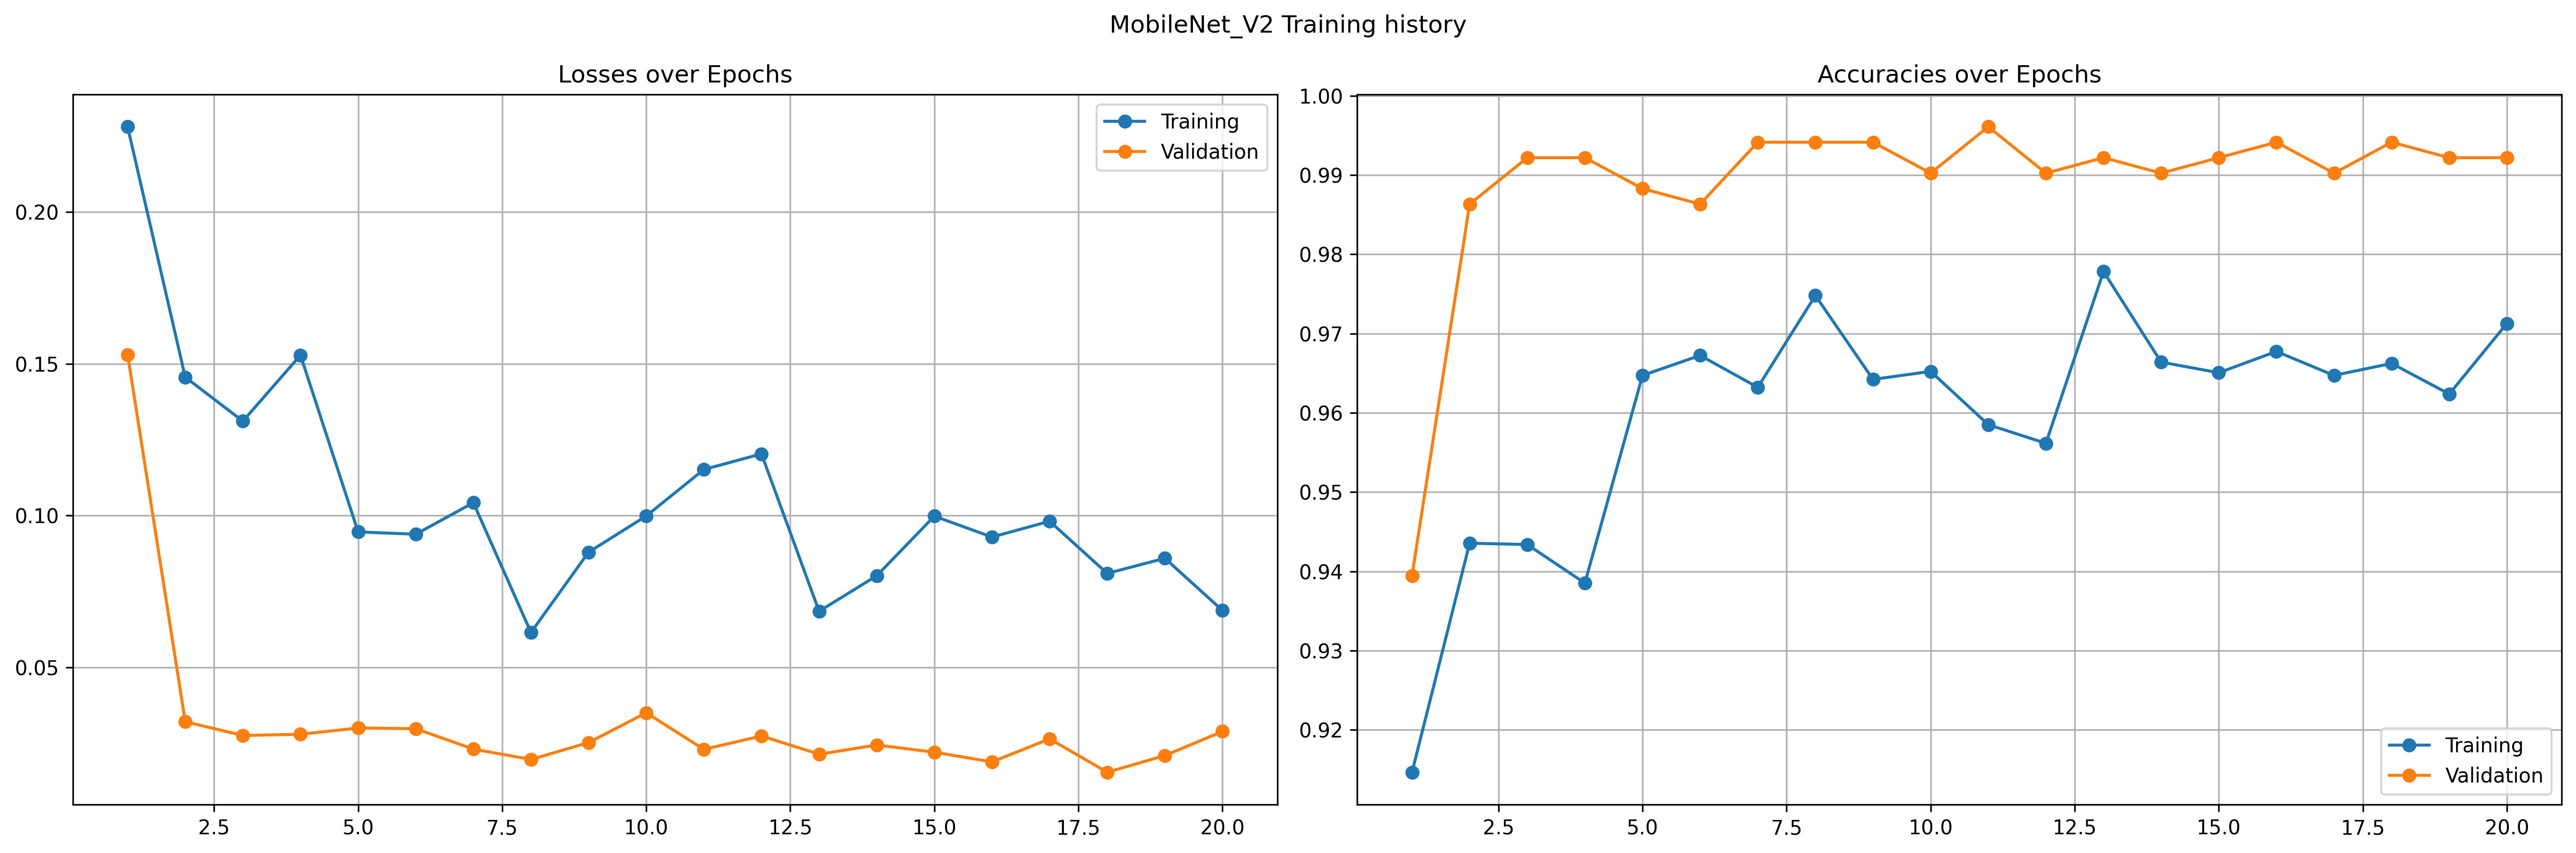

In [10]:
checkpoint = torch.load("./checkpoint/latest_mobilenet_v2.pth", map_location=torch.device("cpu"))
history = checkpoint["history"]

train_loss = history["train_loss"]
train_acc = history["train_acc"]
val_loss = history["val_loss"]
val_acc = history["val_acc"]
epochs = range(1, len(train_loss)+1)


plt.figure(figsize=(18, 6), dpi=300)
plt.suptitle("MobileNet_V2 Training history")

plt.subplot(121)
plt.plot(epochs, train_loss, "o-", label="Training")
plt.plot(epochs, val_loss, "o-", label="Validation")
plt.grid(); plt.legend(); plt.title("Losses over Epochs")

plt.subplot(122)
plt.plot(epochs, train_acc, "o-", label="Training")
plt.plot(epochs, val_acc, "o-", label="Validation")
plt.grid(); plt.legend(); plt.title("Accuracies over Epochs")

plt.tight_layout()
os.makedirs("./checkpoint", exist_ok=True)
plt.savefig("./checkpoint/mobilenet_v2_training_history.png")
plt.show()

### Result on Test Set

In [11]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


IMG_SIZE = 224
BATCH_SIZE = 4
TEST_DIR = "./classification_data/test"
DEVICE = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
checkpoint_path = "./checkpoint/best_mobilenet_v2.pth"

# Test dataset: no augmentation
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Test dataloading
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model loading
model = torchvision.models.mobilenet_v2(weights="DEFAULT")
num_features = model.classifier[1].in_features
num_classes = 2
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

# checkpoint loading
checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))
model.load_state_dict(state_dict=checkpoint["model_state_dict"])
model = model.to(device=DEVICE)
model.eval()

test_accs = []
with torch.inference_mode():
    for X, y in tqdm(test_loader, desc="Predicting", leave=False):
        X, y = X.to(DEVICE), y.to(DEVICE)
        y_pred = model(X)
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        test_acc = (y_pred_class == y).sum().item() / len(y)
        test_accs.append(test_acc)

test_acc = sum(test_accs) / len(test_loader)
print(f"Test accuracy: {test_acc:0.4f}")

Predicting:   0%|          | 0/68 [00:00<?, ?it/s]

Test accuracy: 0.9853


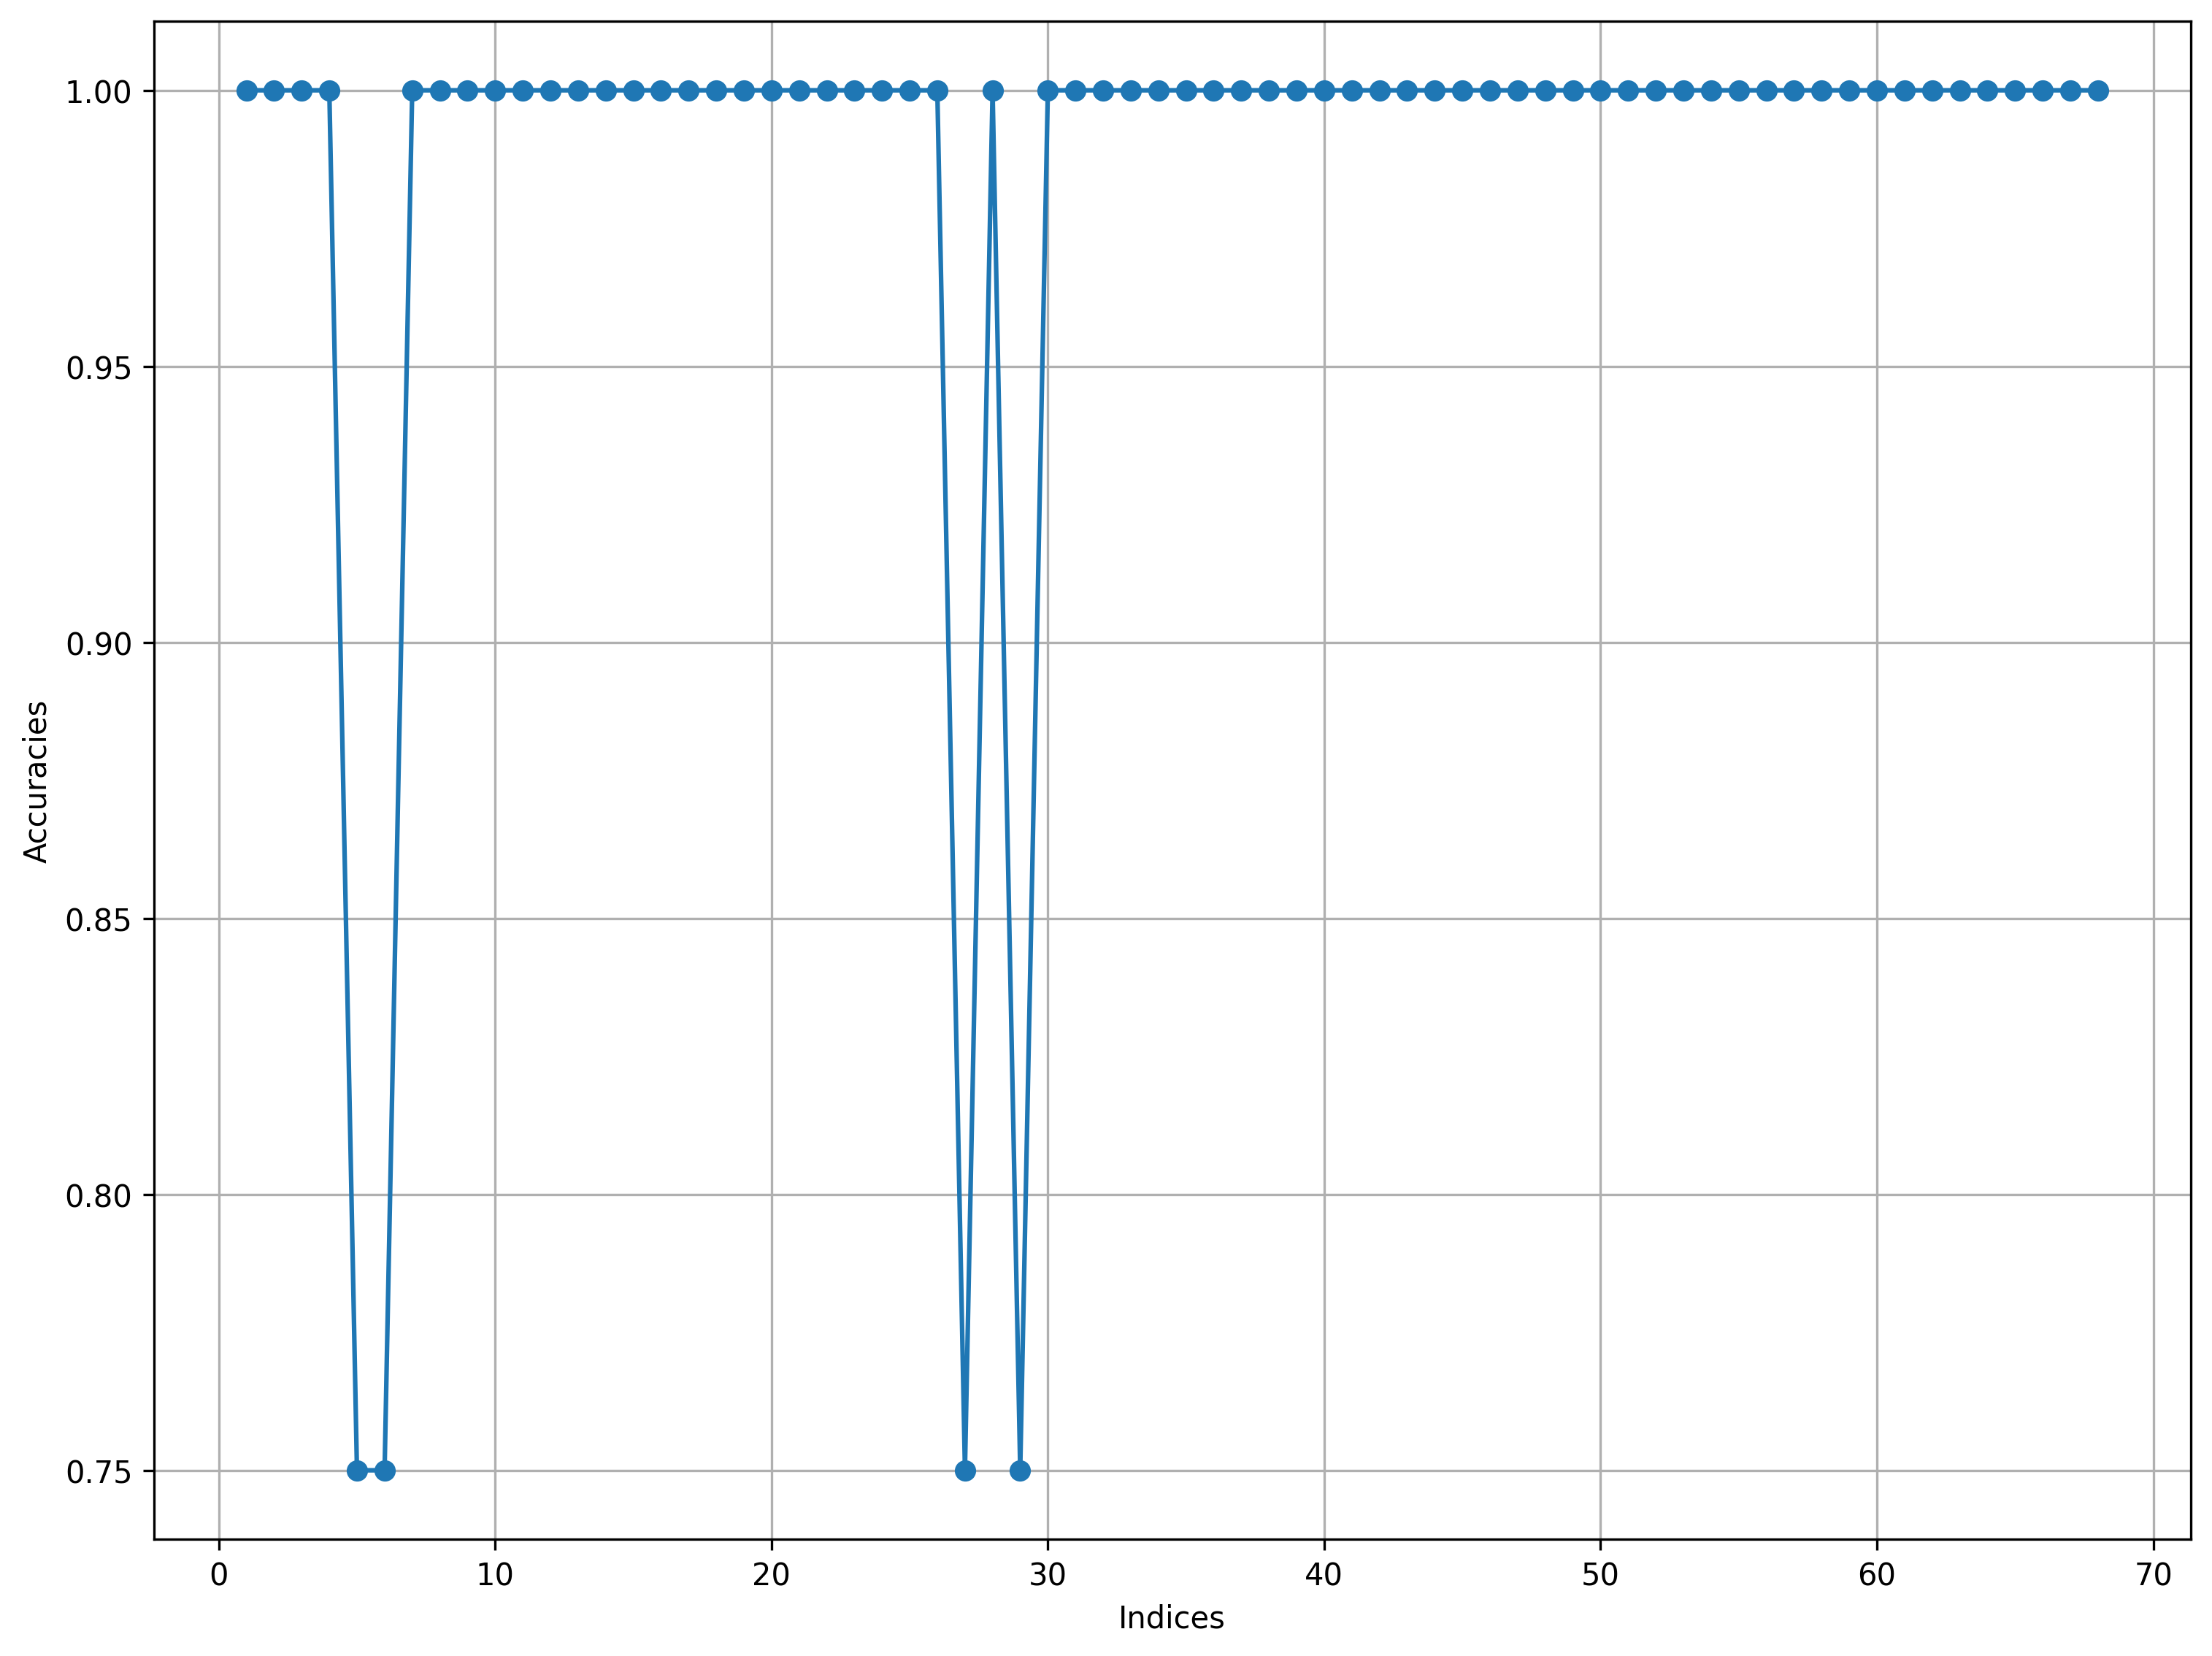

In [12]:
plt.figure(figsize=(12, 9), dpi=300)

plt.plot(range(1, len(test_accs)+1), test_accs, "o-")
plt.xlabel("Indices")
plt.ylabel("Accuracies")
plt.grid()